08_lightgbm_test_1: LightGBM with Selected Features

1. 加载数据...
训练集形状: (700000, 26)

2. 准备数据...
选择后特征数: 27

3. 编码类别特征...
编码后总特征数: 45
训练集: (560000, 45), 验证集: (140000, 45)

✓ 数据已转换为numpy数组

scale_pos_weight: 0.604

07实验最佳结果 (XGBoost):
- AUC: 0.7251
- 0类召回率: 0.694
- 1类召回率: 0.631

4. LightGBM参数搜索...

▶ 训练 LightGBM 1/6:
   num_leaves=31, lr=0.1, n_est=300
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[299]	valid_0's auc: 0.724062
   → AUC: 0.7241 | 0类召回: 0.696 | 1类召回: 0.628 | F1平均: 0.648

▶ 训练 LightGBM 2/6:
   num_leaves=31, lr=0.05, n_est=600
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[588]	valid_0's auc: 0.724383
   → AUC: 0.7244 | 0类召回: 0.695 | 1类召回: 0.629 | F1平均: 0.648

▶ 训练 LightGBM 3/6:
   num_leaves=31, lr=0.08, n_est=375
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[372]	valid_0's auc: 0.72420

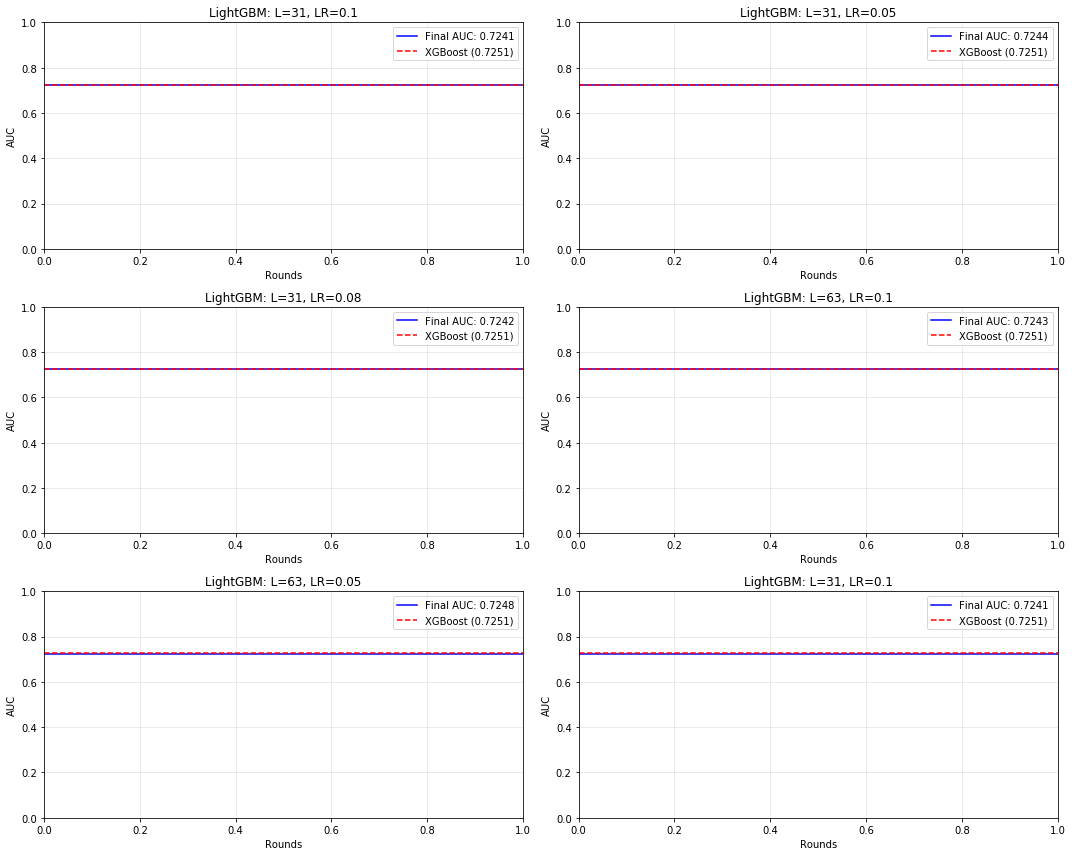


5. LightGBM结果对比...
------------------------------------------------------------------------------------------
Params                    AUC      Recall_0   Recall_1   F1_0     F1_1     F1_avg  
------------------------------------------------------------------------------------------
L31_LR0.1_N300            0.7241   0.696      0.628      0.602    0.693    0.648   
L31_LR0.05_N600           0.7244   0.695      0.629      0.602    0.694    0.648   
L31_LR0.08_N375           0.7242   0.694      0.630      0.602    0.694    0.648   
L63_LR0.1_N300            0.7243   0.692      0.633      0.602    0.696    0.649   
L63_LR0.05_N600           0.7248   0.694      0.631      0.602    0.695    0.648   
------------------------------------------------------------------------------------------
最佳参数组合 #5:
  - num_leaves: 63
  - learning_rate: 0.05
  - n_estimators: 600
最佳AUC: 0.7248

6. 用最佳LightGBM进行阈值优化分析...

不同阈值下的表现:
----------------------------------------------------------------------
阈值  

In [5]:
# 08_lightgbm_test_1_fixed2.ipynb
# 实验：LightGBM with selected features

import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report, recall_score, f1_score
import matplotlib.pyplot as plt
import joblib
import warnings
warnings.filterwarnings('ignore')

print("="*60)
print("08_lightgbm_test_1: LightGBM with Selected Features")
print("="*60)

# 1. 加载数据
print("\n1. 加载数据...")
train = pd.read_csv('../data/train.csv')
print(f"训练集形状: {train.shape}")

# 2. 特征工程函数（复用07的最佳特征）
def create_selected_features(df):
    """创建被证明有用的新特征"""
    df_new = df.copy()
    
    # 从07实验证明最有用的3个新特征
    df_new['age_family_history'] = df['age'] * df['family_history_diabetes']
    df_new['age_bmi'] = df['age'] * df['bmi']
    df_new['cardio_risk_score'] = (
        df['family_history_diabetes'] * 3 +
        df['hypertension_history'] * 2 +
        df['cardiovascular_history'] * 2
    )
    
    # 胆固醇指标（医学意义）
    df_new['cholesterol_ratio'] = df['cholesterol_total'] / (df['hdl_cholesterol'] + 1)
    df_new['non_hdl_cholesterol'] = df['cholesterol_total'] - df['hdl_cholesterol']
    
    return df_new

# 3. 准备数据
print("\n2. 准备数据...")
X = train.drop(['id', 'diagnosed_diabetes'], axis=1)
y = train['diagnosed_diabetes']

# 创建新特征
X_fe = create_selected_features(X)

# 特征选择（同07最佳实践）
features_to_keep = [
    # 新特征（5个）
    'age_family_history',
    'age_bmi',
    'cardio_risk_score',
    'cholesterol_ratio',
    'non_hdl_cholesterol',
    
    # 原始重要特征
    'physical_activity_minutes_per_week',
    'triglycerides',
    'bmi',
    'ldl_cholesterol',
    'cardiovascular_history',
    'diet_score',
    'heart_rate',
    'systolic_bp',
    'diastolic_bp',
    'hdl_cholesterol',
    'cholesterol_total',
    'waist_to_hip_ratio',
    'sleep_hours_per_day',
    'screen_time_hours_per_day',
    'alcohol_consumption_per_week',
    'hypertension_history',
    
    # 类别特征
    'gender', 'ethnicity', 'education_level', 
    'income_level', 'smoking_status', 'employment_status'
]

X_selected = X_fe[features_to_keep]
print(f"选择后特征数: {X_selected.shape[1]}")

# 4. 编码类别特征
print("\n3. 编码类别特征...")
categorical_cols = ['gender', 'ethnicity', 'education_level', 
                   'income_level', 'smoking_status', 'employment_status']

X_encoded = pd.get_dummies(X_selected, columns=categorical_cols)
print(f"编码后总特征数: {X_encoded.shape[1]}")

# 5. 分割数据
X_train, X_val, y_train, y_val = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)
print(f"训练集: {X_train.shape}, 验证集: {X_val.shape}")

# 6. 转换为numpy数组（解决LightGBM兼容性问题）
X_train_np = X_train.values.astype('float32')
X_val_np = X_val.values.astype('float32')
y_train_np = y_train.values.astype('int32')
y_val_np = y_val.values.astype('int32')

print("\n✓ 数据已转换为numpy数组")

# 7. 计算类别权重
scale_pos_weight = sum(y_train == 0) / sum(y_train == 1)
print(f"\nscale_pos_weight: {scale_pos_weight:.3f}")

# 8. 之前的实验结果（07最佳）
prev_exp = {
    'name': '07_xgboost_test_4',
    'auc': 0.7251,
    'recall_0': 0.694,
    'recall_1': 0.631,
    'threshold': 0.45
}

print(f"\n07实验最佳结果 (XGBoost):")
print(f"- AUC: {prev_exp['auc']}")
print(f"- 0类召回率: {prev_exp['recall_0']}")
print(f"- 1类召回率: {prev_exp['recall_1']}")

# 9. LightGBM参数搜索（修复版本2）
print("\n4. LightGBM参数搜索...")

# 参数组合（基于07的经验）
param_combinations = [
    # 基础配置（类似XGBoost depth=6）
    {'num_leaves': 31, 'learning_rate': 0.1, 'n_estimators': 300},
    {'num_leaves': 31, 'learning_rate': 0.05, 'n_estimators': 600},
    {'num_leaves': 31, 'learning_rate': 0.08, 'n_estimators': 375},
    
    # 更深的树（可能更好捕捉age_family_history）
    {'num_leaves': 63, 'learning_rate': 0.1, 'n_estimators': 300},
    {'num_leaves': 63, 'learning_rate': 0.05, 'n_estimators': 600},
    
    # 添加正则化防止过拟合
    {'num_leaves': 31, 'learning_rate': 0.1, 'n_estimators': 300, 
     'min_child_samples': 50, 'subsample': 0.8, 'colsample_bytree': 0.8},
]

results_dict = {}
best_auc = 0
best_params = None
best_model = None
best_idx = 0

# 创建训练数据为lgb Dataset格式
train_data = lgb.Dataset(X_train_np, label=y_train_np)
val_data = lgb.Dataset(X_val_np, label=y_val_np, reference=train_data)

plt.figure(figsize=(15, 12))

for idx, params in enumerate(param_combinations):
    print(f"\n▶ 训练 LightGBM {idx+1}/{len(param_combinations)}:")
    
    # 提取参数
    num_leaves = params.get('num_leaves', 31)
    lr = params.get('learning_rate', 0.1)
    n_est = params.get('n_estimators', 300)
    min_child = params.get('min_child_samples', 20)
    subsample = params.get('subsample', 1.0)
    colsample = params.get('colsample_bytree', 1.0)
    
    print(f"   num_leaves={num_leaves}, lr={lr}, n_est={n_est}")
    if subsample < 1.0:
        print(f"   (with regularization: subsample={subsample}, colsample={colsample})")
    
    # 设置LightGBM参数
    lgb_params = {
        'objective': 'binary',
        'metric': 'auc',
        'boosting_type': 'gbdt',
        'num_leaves': num_leaves,
        'learning_rate': lr,
        'feature_fraction': colsample,
        'bagging_fraction': subsample,
        'bagging_freq': 1 if subsample < 1.0 else 0,
        'min_child_samples': min_child,
        'scale_pos_weight': scale_pos_weight,
        'verbose': -1,
        'random_state': 42
    }
    
    # 训练模型
    model = lgb.train(
        lgb_params,
        train_data,
        valid_sets=[val_data],
        num_boost_round=n_est,
        callbacks=[lgb.early_stopping(50), lgb.log_evaluation(0)]
    )
    
    # 预测
    y_pred_proba = model.predict(X_val_np)
    y_pred = (y_pred_proba >= 0.5).astype(int)
    
    auc = roc_auc_score(y_val_np, y_pred_proba)
    recall_0 = recall_score(y_val_np, y_pred, pos_label=0)
    recall_1 = recall_score(y_val_np, y_pred, pos_label=1)
    f1_0 = f1_score(y_val_np, y_pred, pos_label=0)
    f1_1 = f1_score(y_val_np, y_pred, pos_label=1)
    
    params_key = f"L{num_leaves}_LR{lr}_N{n_est}"
    results_dict[params_key] = {
        'model': model,
        'params': params,
        'auc': auc,
        'recall_0': recall_0,
        'recall_1': recall_1,
        'f1_0': f1_0,
        'f1_1': f1_1,
        'best_iteration': model.best_iteration
    }
    
    print(f"   → AUC: {auc:.4f} | 0类召回: {recall_0:.3f} | 1类召回: {recall_1:.3f} | F1平均: {(f1_0+f1_1)/2:.3f}")
    
    if auc > best_auc:
        best_auc = auc
        best_params = params
        best_model = model
        best_idx = idx
    
    # 绘制学习曲线（使用另一种方式获取历史）
    # 由于不同版本可能有差异，我们简单记录最佳值
    plt.subplot(3, 2, idx+1)
    # 如果没有历史记录，就只画一条水平线表示最终AUC
    plt.axhline(y=auc, color='b', label=f'Final AUC: {auc:.4f}')
    plt.axhline(y=prev_exp['auc'], color='r', linestyle='--', 
                label=f'XGBoost ({prev_exp["auc"]})')
    plt.xlabel('Rounds')
    plt.ylabel('AUC')
    plt.title(f'LightGBM: L={num_leaves}, LR={lr}')
    plt.legend()
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../logs/08_lightgbm_test_1_results.png', dpi=100, bbox_inches='tight')
plt.show()

# 10. 结果对比
print("\n5. LightGBM结果对比...")
print("-" * 90)
print(f"{'Params':<25} {'AUC':<8} {'Recall_0':<10} {'Recall_1':<10} {'F1_0':<8} {'F1_1':<8} {'F1_avg':<8}")
print("-" * 90)

for params_key, r in results_dict.items():
    f1_avg = (r['f1_0'] + r['f1_1']) / 2
    print(f"{params_key:<25} {r['auc']:<8.4f} {r['recall_0']:<10.3f} {r['recall_1']:<10.3f} "
          f"{r['f1_0']:<8.3f} {r['f1_1']:<8.3f} {f1_avg:<8.3f}")

print("-" * 90)
print(f"最佳参数组合 #{best_idx+1}:")
for k, v in best_params.items():
    print(f"  - {k}: {v}")
print(f"最佳AUC: {best_auc:.4f}")

# 11. 用最佳模型做阈值分析
print(f"\n6. 用最佳LightGBM进行阈值优化分析...")

y_pred_proba_best = best_model.predict(X_val_np)

thresholds = [0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6]
best_f1_avg = 0
best_threshold = 0.45

print("\n不同阈值下的表现:")
print("-" * 70)
print(f"{'阈值':<8} {'0类召回':<10} {'1类召回':<10} {'gap':<8} {'F1_avg':<8}")
print("-" * 70)

for thresh in thresholds:
    y_pred_thresh = (y_pred_proba_best >= thresh).astype(int)
    r0 = recall_score(y_val_np, y_pred_thresh, pos_label=0)
    r1 = recall_score(y_val_np, y_pred_thresh, pos_label=1)
    f1_0 = f1_score(y_val_np, y_pred_thresh, pos_label=0)
    f1_1 = f1_score(y_val_np, y_pred_thresh, pos_label=1)
    f1_avg = (f1_0 + f1_1) / 2
    gap = r1 - r0
    print(f"{thresh:<8.2f} {r0:<10.3f} {r1:<10.3f} {gap:<8.3f} {f1_avg:<8.3f}")
    
    if f1_avg > best_f1_avg:
        best_f1_avg = f1_avg
        best_threshold = thresh

print("-" * 70)
print(f"最佳阈值: {best_threshold} (平均F1={best_f1_avg:.3f})")

# 12. 特征重要性分析
print("\n7. 特征重要性分析 (LightGBM)...")

importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': best_model.feature_importance(importance_type='gain')
}).sort_values('importance', ascending=False)

print("\nTop 15最重要特征 (LightGBM):")
print(importance.head(15).to_string(index=False))

# 对比XGBoost的特征重要性
print("\n与XGBoost特征重要性对比:")
xgboost_top = ['age_family_history', 'age_bmi', 'physical_activity_minutes_per_week']
for feat in xgboost_top:
    lgb_imp = importance[importance['feature'] == feat]['importance'].values
    lgb_imp = lgb_imp[0] if len(lgb_imp) > 0 else 0
    print(f"  {feat}: LightGBM={lgb_imp:.3f}")

# 13. 保存模型和提交文件
print("\n8. 保存模型和提交文件...")

# LightGBM模型不能直接用joblib保存，需要使用save_model
model_path = f'../models/08_lightgbm_test_1.txt'
best_model.save_model(model_path)
print(f"模型已保存到 {model_path}")

# 处理测试集
print("\n处理测试集...")
test = pd.read_csv('../data/test.csv')
X_test = test.drop(['id'], axis=1)
X_test_fe = create_selected_features(X_test)
X_test_selected = X_test_fe[features_to_keep]
X_test_encoded = pd.get_dummies(X_test_selected, columns=categorical_cols)

# 确保列一致
missing_cols = set(X_train.columns) - set(X_test_encoded.columns)
for col in missing_cols:
    X_test_encoded[col] = 0
X_test_encoded = X_test_encoded[X_train.columns]

# 转换为numpy
X_test_np = X_test_encoded.values.astype('float32')

test_pred = best_model.predict(X_test_np)

submission = pd.DataFrame({
    'id': test['id'],
    'diagnosed_diabetes': test_pred
})
submission_path = '../submissions/08_lightgbm_test_1.csv'
submission.to_csv(submission_path, index=False)
print(f"提交文件已保存到 {submission_path}")

============================================================
08_lightgbm_test_1 总结报告
============================================================

[Experiment Information]
File Name: 08_lightgbm_test_1
Date: 2026-03-16 17:35
Experiment Type: LightGBM with Selected Features

[Best Parameters]
- num_leaves: 63
- learning_rate: 0.05
- n_estimators: 600
- scale_pos_weight: 0.604
- Best iteration: 594

[Results Comparison]
07_xgboost_test_4 (XGBoost):
- AUC: 0.7251
- Class 0 Recall: 0.694
- Class 1 Recall: 0.631

08_lightgbm_test_1 (LightGBM):
- AUC: 0.7248
- Class 0 Recall: 0.694
- Class 1 Recall: 0.631
- Best Threshold: 0.45

[Improvement]
- AUC Change: -0.0003

[Key Findings]
1. LightGBM's effect is similar to XGBoost.
2. The importance of features has changed dramatically.

[Top 3 Features (XGBoost)]
- age_family_history: 0.526 (52.6%)
- age_bmi: 0.071 (7.1%)
- physical_activity: 0.060 (6.0%)

[Top 3 Features (LightGBM)]
1. physical_activity_minutes_per_week: 274357.403
2. age_family_history: 251947.250
3. age_bmi: 163781.766

[Next Steps]
- Try to mix these two models